# PEMS-XGBoost CO — evaluación interpolativa FINAL R1F_STD

**Propósito:** consumir sin cambios la configuración FROZEN producida por
`07_XGBoost_CO_INTERP_OPT - R1_POC_EFFICIENT.ipynb`, entrenar diez modelos con DEV completo y evaluar
una sola vez el TEST interpolativo.

**Entradas:** protocolo R1, `BEST_CONFIG`, política final y manifiesto
FROZEN del notebook OPT. **Salidas:** modelos UBJ, predicciones, métricas por
semilla y ensamble, diagnósticos por decil, importancia, complejidad,
almacenamiento y latencia CPU.

**Estado:** FINAL / STANDARDIZED. No contiene Optuna ni reabre decisiones.
XGBoost es exclusivamente data-driven; no aplica restricciones monotónicas,
física, sintéticos, escalamiento de X ni clipping de predicciones.

## Mapa del notebook

| Sección | Finalidad |
|---|---|
| SEC-01 | entorno, rutas y utilidades |
| SEC-02 | autenticación de protocolo y OPT FROZEN |
| SEC-03 | carga exclusiva de DEV |
| SEC-04 | entrenamiento final de diez semillas |
| SEC-05 | puerta previa y apertura única de TEST |
| SEC-06 | evaluación por semilla y ensamble |
| SEC-07 | diagnósticos, importancia y figuras |
| SEC-08 | complejidad, bytes y latencia CPU |
| SEC-09 | manifiesto, hashes y cierre |


## SEC-01 — Entorno, rutas y utilidades

### C-01.01 / CFG-01 — Bootstrap y configuración operativa

El backend puede ser CPU/CUDA, pero la configuración científica y las diez
semillas se leen exclusivamente de los artefactos FROZEN.


In [1]:
# [C-01.01] Bootstrap, imports y constantes
import importlib.metadata
import importlib.util
import os
import re
import subprocess
import sys
from pathlib import Path

PROJECT_ROOT_PATH = os.environ.get(
    "PEMS_PROJECT_ROOT",
    "/content/drive/MyDrive/Turbine_Emissions_PINN",
)
DEVICE_PREFERENCE = os.environ.get("PEMS_XGB_DEVICE", "AUTO").upper()
if DEVICE_PREFERENCE not in {"AUTO", "CPU", "CUDA"}:
    raise ValueError("DEVICE_PREFERENCE debe ser AUTO, CPU o CUDA")

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "xgboost": "xgboost>=2.0",
    "psutil": "psutil",
}
minimum_versions = {"xgboost": (2, 0)}


def major_minor(version_text: str) -> tuple[int, int]:
    numbers = [int(item) for item in re.findall(r"\d+", version_text)]
    return tuple((numbers + [0, 0])[:2])


missing_packages = []
for module, package in required_packages.items():
    if importlib.util.find_spec(module) is None:
        missing_packages.append(package)
        continue
    minimum = minimum_versions.get(module)
    if minimum is None:
        continue
    try:
        installed = importlib.metadata.version(module)
    except importlib.metadata.PackageNotFoundError:
        missing_packages.append(package)
        continue
    if major_minor(installed) < minimum:
        missing_packages.append(package)

if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

from dataclasses import dataclass
from datetime import datetime, timezone
import hashlib
import importlib.metadata
import json
import math
import platform
import random
import shutil
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import xgboost as xgb
from IPython.display import display
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

VERSION = "XGBOOST_CO_INTERP_FINAL_R1F_STD"
PROTOCOL_VERSION = "INTERP_PROTOCOL_R1"
OPT_VERSION = "XGBOOST_CO_INTERP_OPT_R1_POC_EFFICIENT"
CURRENT_NOTEBOOK_NAME = "07_XGBoost_CO_INTERP_FINAL - R1F_STD.ipynb"
PROTOCOL_NOTEBOOK_NAME = "00_PEMS_PINN_INTERP_PROTOCOL - R1.ipynb"
OPT_NOTEBOOK_NAME = "07_XGBoost_CO_INTERP_OPT - R1_POC_EFFICIENT.ipynb"
FEATURES = [
    "AT", "AP", "AH", "AFDP", "GTEP",
    "TIT", "TAT", "TEY", "CDP",
]
TARGET = "CO"
OTHER_TARGET = "CO" if TARGET == "NOX" else "NOX"
PURE_DATA_DRIVEN = True
RAW_DATA_REL = Path("data") / "raw"
PROTOCOL_REL = Path("models") / "interp" / "work_pinn_interp_protocol"
OPT_REL = Path("models/interp/work_xgboost_co_interp_opt_r1_poc_efficient")
OUTPUT_REL = Path("models/interp/work_xgboost_co_interp_final_r1f_std")
REPRESENTATIVE_SEED = 42
LATENCY_WARMUP = 50
LATENCY_REPETITIONS = 200
THROUGHPUT_WARMUP = 10
THROUGHPUT_REPETITIONS = 30


### C-01.02 / CHK-01 — Utilidades, rutas y backend

**Control:** raíz canónica explícita, escritura atómica y selección única
del dispositivo. La medición de despliegue se ejecuta en CPU.


In [2]:
# [C-01.02] Utilidades, rutas e inicialización
def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def sha256_bytes(payload: bytes) -> str:
    return hashlib.sha256(payload).hexdigest()


def canonical_json_hash(payload: dict) -> str:
    encoded = json.dumps(
        payload,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
    return sha256_bytes(encoded)


def atomic_text(path: Path, text: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(
        mode="w",
        encoding="utf-8",
        dir=path.parent,
        delete=False,
    ) as handle:
        handle.write(text)
        temporary = Path(handle.name)
    temporary.replace(path)


def atomic_json(path: Path, payload: dict) -> None:
    atomic_text(path, json.dumps(payload, ensure_ascii=False, indent=2))


def atomic_csv(path: Path, frame: pd.DataFrame) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(
        mode="w",
        encoding="utf-8",
        newline="",
        dir=path.parent,
        delete=False,
    ) as handle:
        frame.to_csv(handle, index=False)
        temporary = Path(handle.name)
    temporary.replace(path)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)


@dataclass(frozen=True)
class FinalPaths:
    work: Path
    audit: Path
    configs: Path
    figures_test: Path
    figures_summary: Path
    models: Path
    reports: Path
    tables: Path


def validate_project_root(path_value: str) -> Path:
    root = Path(path_value).expanduser().resolve()
    missing = [
        root / RAW_DATA_REL / f"gt_{year}.csv"
        for year in range(2011, 2016)
        if not (root / RAW_DATA_REL / f"gt_{year}.csv").is_file()
    ]
    if missing:
        raise FileNotFoundError(f"CSV canónicos ausentes: {missing}")
    return root


def create_paths(root: Path) -> FinalPaths:
    work = root / OUTPUT_REL
    paths = FinalPaths(
        work=work,
        audit=work / "audit",
        configs=work / "configs",
        figures_test=work / "figures" / "test",
        figures_summary=work / "figures" / "summary",
        models=work / "models",
        reports=work / "reports",
        tables=work / "tables",
    )
    for path in paths.__dict__.values():
        Path(path).mkdir(parents=True, exist_ok=True)
    return paths


def select_device() -> str:
    if DEVICE_PREFERENCE == "CPU":
        return "cpu"
    wants_cuda = DEVICE_PREFERENCE == "CUDA" or (
        DEVICE_PREFERENCE == "AUTO" and shutil.which("nvidia-smi") is not None
    )
    if not wants_cuda:
        return "cpu"
    try:
        probe = xgb.XGBRegressor(
            n_estimators=2,
            tree_method="hist",
            device="cuda",
            verbosity=0,
        )
        probe.fit(
            np.arange(64, dtype=np.float32).reshape(32, 2),
            np.arange(32, dtype=np.float32),
            verbose=False,
        )
        return "cuda"
    except (xgb.core.XGBoostError, RuntimeError) as exc:
        if DEVICE_PREFERENCE == "CUDA":
            raise RuntimeError("Preflight CUDA falló") from exc
        return "cpu"


PROJECT_ROOT = validate_project_root(PROJECT_ROOT_PATH)
PATHS = create_paths(PROJECT_ROOT)
DEVICE = select_device()
XGB_N_JOBS = 1 if DEVICE == "cuda" else max(
    1,
    min(8, psutil.cpu_count(logical=False) or 1),
)
TEST_ACCESS_COUNT = 0
ENVIRONMENT = {
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "device_training": DEVICE,
    "python": sys.version,
    "platform": platform.platform(),
    "cpu_physical": psutil.cpu_count(logical=False),
    "cpu_logical": psutil.cpu_count(logical=True),
    "packages": {
        name: importlib.metadata.version(name)
        for name in ["numpy", "pandas", "scikit-learn", "xgboost"]
    },
}
atomic_json(
    PATHS.audit / "ENVIRONMENT_XGBOOST_CO_FINAL_R1F_STD.json",
    ENVIRONMENT,
)
print({"CHK-01": "PASS", "device": DEVICE, "salida": str(PATHS.work)})


{'CHK-01': 'PASS', 'device': 'cuda', 'salida': 'C:\\ChatGPT-Work\\Walk_Forward R8\\models\\interp\\work_xgboost_co_interp_final_r1f_std'}


## SEC-02 — Autenticación de protocolo y OPT FROZEN

### C-02.01 / ALG-01 / CHK-02 — Contrato cruzado

**Lógica:** autenticar asignación y folds; validar manifiesto OPT, hashes de
configuración/política, consumidor autorizado, contrato data-driven y
ausencia de acceso previo a TEST.


In [3]:
# [C-02.01] Verificación integral de entradas FROZEN
def verify_frozen_inputs(root: Path):
    protocol_base = root / PROTOCOL_REL
    protocol_paths = {
        "split": protocol_base / "manifests" / "INTERP_SPLIT_MANIFEST.json",
        "folds": protocol_base / "manifests" / "INTERP_FOLDS_MANIFEST.json",
        "domain": protocol_base / "manifests" / "INTERP_DOMAIN_ENVELOPE.json",
        "general": (
            protocol_base
            / "manifests"
            / "MANIFIESTO_ARTEFACTOS_INTERP_PROTOCOL.json"
        ),
        "assignment": protocol_base / "tables" / "INTERP_ROW_ASSIGNMENT.csv",
    }
    opt_base = root / OPT_REL
    opt_paths = {
        "best_config": (
            opt_base
            / "configs"
            / "BEST_CONFIG_XGBOOST_CO_INTERP.json"
        ),
        "policy": (
            opt_base
            / "configs"
            / "FINAL_TRAINING_POLICY_XGBOOST_CO_INTERP_R1.json"
        ),
        "frozen": (
            opt_base
            / "configs"
            / "FROZEN_CONFIG_MANIFEST_XGBOOST_CO_INTERP_R1.json"
        ),
        "handoff": (
            opt_base
            / "reports"
            / "HANDOFF_XGBOOST_CO_OPT_TO_FINAL_R1.json"
        ),
    }
    required = {**protocol_paths, **opt_paths}
    missing = [str(path) for path in required.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Entradas FROZEN ausentes: {missing}")

    split = json.loads(protocol_paths["split"].read_text(encoding="utf-8"))
    folds = json.loads(protocol_paths["folds"].read_text(encoding="utf-8"))
    domain = json.loads(protocol_paths["domain"].read_text(encoding="utf-8"))
    general = json.loads(protocol_paths["general"].read_text(encoding="utf-8"))
    for name, manifest in {
        "split": split,
        "folds": folds,
        "domain": domain,
        "general": general,
    }.items():
        if manifest.get("status") != "FROZEN":
            raise RuntimeError(f"Protocolo {name} no FROZEN")
        if manifest.get("protocol_version") != PROTOCOL_VERSION:
            raise RuntimeError(f"Versión inesperada en {name}")

    declared = {
        str(item["path"]).replace("\\", "/"): item["sha256"]
        for item in general.get("artifacts", [])
    }
    canonical = {
        "manifests/INTERP_SPLIT_MANIFEST.json": protocol_paths["split"],
        "manifests/INTERP_FOLDS_MANIFEST.json": protocol_paths["folds"],
        "manifests/INTERP_DOMAIN_ENVELOPE.json": protocol_paths["domain"],
        "tables/INTERP_ROW_ASSIGNMENT.csv": protocol_paths["assignment"],
    }
    for relative, path in canonical.items():
        if declared.get(relative) != sha256_file(path):
            raise RuntimeError(f"Artefacto de protocolo no autenticado: {relative}")

    assignment = pd.read_csv(protocol_paths["assignment"])
    assignment_hash = sha256_file(protocol_paths["assignment"])
    if assignment_hash != split.get("row_assignment_sha256"):
        raise RuntimeError("Hash assignment inconsistente")
    fold_payload = (
        assignment.loc[
            assignment.partition.eq("DEV"),
            ["block_id", "cv_role", "cv_fold"],
        ]
        .drop_duplicates()
        .sort_values("block_id")
    )
    fold_hash = sha256_bytes(
        fold_payload.to_csv(index=False, lineterminator="\n").encode("utf-8")
    )
    if fold_hash != folds.get("fold_assignment_sha256"):
        raise RuntimeError("Hash folds inconsistente")

    best_config = json.loads(
        opt_paths["best_config"].read_text(encoding="utf-8")
    )
    policy = json.loads(opt_paths["policy"].read_text(encoding="utf-8"))
    frozen = json.loads(opt_paths["frozen"].read_text(encoding="utf-8"))
    handoff = json.loads(opt_paths["handoff"].read_text(encoding="utf-8"))
    if any(
        item.get("status") != "FROZEN"
        for item in [best_config, policy, frozen]
    ):
        raise RuntimeError("OPT no está completamente FROZEN")
    if handoff.get("status") != "READY":
        raise RuntimeError("Handoff OPT no está READY")
    if any(
        item.get("version") != OPT_VERSION
        for item in [best_config, policy, frozen, handoff]
    ):
        raise RuntimeError("Versión OPT inconsistente")
    if any(
        item.get("target") != TARGET
        for item in [best_config, policy, frozen, handoff]
    ):
        raise RuntimeError("Target inconsistente en artefactos OPT")
    if frozen.get("producer_notebook") != OPT_NOTEBOOK_NAME:
        raise RuntimeError("Productor OPT inesperado")
    if frozen.get("authorized_consumer") != CURRENT_NOTEBOOK_NAME:
        raise RuntimeError("Este notebook no es el consumidor autorizado")
    if frozen.get("campaign_complete") is not True:
        raise RuntimeError("La campaña OPT no quedó completa")
    if any(
        value is not False
        for value in [
            best_config.get("test_opened"),
            policy.get("test_used"),
            frozen.get("test_opened"),
            handoff.get("test_opened"),
        ]
    ):
        raise RuntimeError("OPT declara acceso indebido a TEST")
    if handoff.get("source_notebook") != OPT_NOTEBOOK_NAME:
        raise RuntimeError("Fuente del handoff inesperada")
    if handoff.get("destination_notebook") != CURRENT_NOTEBOOK_NAME:
        raise RuntimeError("Destino del handoff inesperado")
    expected_frozen_rel = str(
        opt_paths["frozen"].relative_to(root)
    ).replace("\\", "/")
    declared_frozen_rel = str(
        handoff.get("frozen_manifest_path", "")
    ).replace("\\", "/")
    if declared_frozen_rel != expected_frozen_rel:
        raise RuntimeError("Ruta del manifiesto FROZEN no autenticada")
    if handoff.get("frozen_manifest_sha256") != sha256_file(
        opt_paths["frozen"]
    ):
        raise RuntimeError("Hash del manifiesto FROZEN inconsistente")
    if frozen.get("best_config_sha256") != sha256_file(opt_paths["best_config"]):
        raise RuntimeError("Hash BEST_CONFIG inconsistente")
    if frozen.get("training_policy_sha256") != sha256_file(opt_paths["policy"]):
        raise RuntimeError("Hash training policy inconsistente")
    config_hashes = {
        best_config.get("config_hash"),
        policy.get("config_hash"),
        frozen.get("config_hash"),
        handoff.get("config_hash"),
    }
    if len(config_hashes) != 1 or None in config_hashes:
        raise RuntimeError("Config hash difiere entre artefactos")
    hash_payload = dict(best_config)
    declared_config_hash = hash_payload.pop("config_hash")
    if canonical_json_hash(hash_payload) != declared_config_hash:
        raise RuntimeError("Contenido BEST_CONFIG no coincide con config_hash")
    pure = best_config.get("pure_data_driven_contract", {})
    if frozen.get("pure_data_driven_contract") != pure:
        raise RuntimeError("Contrato data-driven difiere en el manifiesto")
    if not pure.get("pure_data_driven"):
        raise RuntimeError("BEST_CONFIG no declara modelo data-driven")
    if pure.get("monotone_constraints") is not None:
        raise RuntimeError("BEST_CONFIG contiene monotonía")
    if best_config.get("features") != FEATURES:
        raise RuntimeError("BEST_CONFIG no utiliza RAW_9 canónico")
    if TARGET == "NOX" and best_config.get("target_transform") != "identity":
        raise RuntimeError("NOx FINAL exige identity")
    if TARGET == "CO" and best_config.get("target_transform") not in {
        "identity",
        "log1p",
    }:
        raise RuntimeError("Transformación CO no autorizada")
    if assignment_hash != frozen.get("row_assignment_sha256"):
        raise RuntimeError("OPT y protocolo difieren en assignment")
    if fold_hash != frozen.get("fold_assignment_sha256"):
        raise RuntimeError("OPT y protocolo difieren en folds")

    expected_hashes = {
        Path(str(item["path"]).replace("\\", "/")).name: item["sha256"]
        for item in split["data_hashes"]
    }
    for year in range(2011, 2016):
        raw_path = root / RAW_DATA_REL / f"gt_{year}.csv"
        if expected_hashes.get(raw_path.name) != sha256_file(raw_path):
            raise RuntimeError(f"Hash inesperado para {raw_path.name}")

    return {
        "assignment": assignment,
        "assignment_hash": assignment_hash,
        "fold_hash": fold_hash,
        "protocol_general_sha256": sha256_file(protocol_paths["general"]),
        "best_config": best_config,
        "policy": policy,
        "frozen": frozen,
        "handoff": handoff,
        "paths": opt_paths,
    }


FROZEN = verify_frozen_inputs(PROJECT_ROOT)
ASSIGNMENT = FROZEN["assignment"]
BEST_CONFIG = FROZEN["best_config"]
FINAL_TRAINING_POLICY = FROZEN["policy"]
FINAL_SEEDS = [int(seed) for seed in FINAL_TRAINING_POLICY["final_seeds"]]
FINAL_N_ESTIMATORS = int(FINAL_TRAINING_POLICY["final_n_estimators"])
ENSEMBLE_RULE = FINAL_TRAINING_POLICY["ensemble_rule"]
expected_seeds = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210]
if FINAL_SEEDS != expected_seeds:
    raise RuntimeError("La política no contiene las diez semillas predeclaradas")
if ENSEMBLE_RULE != "arithmetic_mean_all_predeclared_seeds":
    raise RuntimeError("Regla de ensamble inesperada")
print(
    {
        "CHK-02": "PASS",
        "config_hash": BEST_CONFIG["config_hash"],
        "final_n_estimators": FINAL_N_ESTIMATORS,
        "seeds": len(FINAL_SEEDS),
    }
)


{'CHK-02': 'PASS', 'config_hash': '9c254d014635ed5849756616f5ed8ef37b078c2ae7c2cf149831a2a07060d629', 'final_n_estimators': 320, 'seeds': 10}


## SEC-03 — Carga exclusiva de DEV

### C-03.01 / ALG-02 / CHK-03 — Barrera assignment-first

TEST no se materializa en esta sección. La función genérica se reutilizará
una sola vez más después de la puerta previa, exclusivamente para TEST.


In [4]:
# [C-03.01] Materialización controlada por partición
def load_partition_authorized(
    root: Path,
    assignment: pd.DataFrame,
    partition: str,
) -> pd.DataFrame:
    if partition not in {"DEV", "TEST"}:
        raise ValueError("partition debe ser DEV o TEST")
    frames = []
    for year in range(2011, 2016):
        meta = assignment.loc[assignment.year.eq(year)].sort_values(
            "row_in_year"
        )
        selected = meta.loc[meta.partition.eq(partition)].copy()
        allowed_rows = set(selected.row_in_year.astype(int).tolist())
        raw_path = root / RAW_DATA_REL / f"gt_{year}.csv"
        header = pd.read_csv(raw_path, nrows=0).columns.tolist()
        if not set(FEATURES + [TARGET, OTHER_TARGET]).issubset(header):
            raise ValueError(f"Columnas faltantes en {raw_path.name}")
        row_filter = (
            lambda line, allowed=allowed_rows: (
                line > 0 and (line - 1) not in allowed
            )
        )
        x_selected = pd.read_csv(
            raw_path,
            usecols=FEATURES,
            skiprows=row_filter,
        )[FEATURES]
        y_selected = pd.read_csv(
            raw_path,
            usecols=[TARGET],
            skiprows=row_filter,
        )
        if len(x_selected) != len(selected) or len(y_selected) != len(selected):
            raise RuntimeError(f"Carga {partition} falló en {year}")
        identity_columns = [
            "global_row_id",
            "year",
            "row_in_year",
            "block_id",
            "partition",
            "cv_role",
            "cv_fold",
        ]
        frames.append(
            pd.concat(
                [
                    selected[identity_columns].reset_index(drop=True),
                    x_selected.reset_index(drop=True),
                    y_selected.reset_index(drop=True),
                ],
                axis=1,
            )
        )
    data = pd.concat(frames, ignore_index=True)
    if not data.partition.eq(partition).all():
        raise RuntimeError(f"La carga {partition} mezcló particiones")
    if data.global_row_id.duplicated().any():
        raise RuntimeError(f"IDs duplicados en {partition}")
    if not np.isfinite(data[FEATURES + [TARGET]].to_numpy(float)).all():
        raise ValueError(f"NaN/Inf en {partition}")
    return data


DEV_DATA = load_partition_authorized(PROJECT_ROOT, ASSIGNMENT, "DEV")
TARGET_ACCESS_AUDIT_PRE_TEST = {
    "status": "PASS",
    "generated_at_utc": utc_now(),
    "target": TARGET,
    "dev_target_rows_materialized": len(DEV_DATA),
    "test_target_rows_materialized": 0,
    "test_access_count": TEST_ACCESS_COUNT,
    "other_pollutant_materialized": False,
}
atomic_json(
    PATHS.audit / "TARGET_ACCESS_AUDIT_PRE_TEST_R1F_STD.json",
    TARGET_ACCESS_AUDIT_PRE_TEST,
)
print({"CHK-03": "PASS", "DEV_rows": len(DEV_DATA), "TEST_y_rows": 0})


{'CHK-03': 'PASS', 'DEV_rows': 29845, 'TEST_y_rows': 0}

## SEC-04 — Entrenamiento final con DEV completo

### C-04.01 / ALG-03 — Núcleo y política congelada

Se ajustan exactamente `final_n_estimators` árboles para cada semilla. No
hay validación interna, early stopping ni selección posterior de semillas.


In [5]:
# [C-04.01] Transformaciones, métricas y constructor final
def target_forward(values, transform: str) -> np.ndarray:
    array = np.asarray(values, dtype=float)
    if transform == "identity":
        return array.copy()
    if transform == "log1p":
        if np.min(array) <= -1:
            raise ValueError("log1p requiere objetivo > -1")
        return np.log1p(array)
    raise ValueError(f"Transformación desconocida: {transform}")


def target_inverse(values, transform: str) -> np.ndarray:
    array = np.asarray(values, dtype=float)
    if transform == "identity":
        return array.copy()
    if transform == "log1p":
        return np.expm1(array)
    raise ValueError(f"Transformación desconocida: {transform}")


def predictive_metrics(y_true, y_pred) -> dict:
    observed = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    residual = predicted - observed
    threshold = float(np.quantile(observed, 0.90))
    tail = observed >= threshold
    return {
        "R2": float(r2_score(observed, predicted)),
        "RMSE": float(np.sqrt(mean_squared_error(observed, predicted))),
        "MAE": float(mean_absolute_error(observed, predicted)),
        "bias": float(np.mean(residual)),
        "negative_prediction_pct": float(np.mean(predicted < 0) * 100),
        "tail_threshold": threshold,
        "tail_RMSE": float(
            np.sqrt(mean_squared_error(observed[tail], predicted[tail]))
        ),
        "tail_MAE": float(mean_absolute_error(observed[tail], predicted[tail])),
        "tail_bias": float(np.mean(residual[tail])),
    }


def final_model_parameters(seed: int) -> dict:
    parameters = {
        **BEST_CONFIG["fixed_xgb_parameters"],
        **BEST_CONFIG["xgb_parameters"],
        "n_estimators": FINAL_N_ESTIMATORS,
        "random_state": int(seed),
        "device": DEVICE,
        "n_jobs": XGB_N_JOBS,
        "eval_metric": "rmse",
    }
    forbidden = {"monotone_constraints", "interaction_constraints"}
    if forbidden & set(parameters):
        raise RuntimeError("El constructor final contiene restricciones")
    return parameters


### C-04.02 / ART-01 / CHK-04 — Diez modelos congelados antes de TEST

Cada modelo se serializa en UBJ junto con metadatos y hash. Los diez deben
existir antes de permitir la apertura del objetivo TEST.


In [6]:
# [C-04.02] Entrenamiento final multisemilla
FINAL_MODELS = {}
TRAINING_ROWS = []
x_dev = DEV_DATA[FEATURES]
target_transform = BEST_CONFIG["target_transform"]
y_dev_model = target_forward(DEV_DATA[TARGET], target_transform)
training_started = time.perf_counter()

for seed in FINAL_SEEDS:
    set_seed(seed)
    started = time.perf_counter()
    model = xgb.XGBRegressor(**final_model_parameters(seed))
    model.fit(x_dev, y_dev_model, verbose=False)
    elapsed = time.perf_counter() - started
    model_path = PATHS.models / f"XGBOOST_{TARGET}_INTERP_seed{seed}.ubj"
    model.save_model(model_path)
    metadata = {
        "status": "FROZEN_BEFORE_TEST",
        "seed": seed,
        "target": TARGET,
        "features": FEATURES,
        "target_transform": target_transform,
        "config_hash": BEST_CONFIG["config_hash"],
        "n_estimators": FINAL_N_ESTIMATORS,
        "model_path": str(model_path.relative_to(PROJECT_ROOT)).replace(
            "\\", "/"
        ),
        "model_sha256": sha256_file(model_path),
        "test_used": False,
    }
    atomic_json(
        PATHS.models / f"XGBOOST_{TARGET}_INTERP_seed{seed}.metadata.json",
        metadata,
    )
    FINAL_MODELS[seed] = model
    TRAINING_ROWS.append(
        {
            "seed": seed,
            "N_DEV": len(DEV_DATA),
            "n_estimators": FINAL_N_ESTIMATORS,
            "elapsed_seconds": elapsed,
            "model_bytes": model_path.stat().st_size,
            "model_sha256": metadata["model_sha256"],
        }
    )

FINAL_TRAINING_SECONDS = time.perf_counter() - training_started
TRAINING_SUMMARY = pd.DataFrame(TRAINING_ROWS)
atomic_csv(PATHS.tables / "training_summary_by_seed.csv", TRAINING_SUMMARY)
if set(FINAL_MODELS) != set(FINAL_SEEDS) or len(FINAL_MODELS) != 10:
    raise RuntimeError("No se congelaron exactamente diez modelos")
print(
    {
        "CHK-04": "PASS",
        "modelos": len(FINAL_MODELS),
        "tiempo_total_s": FINAL_TRAINING_SECONDS,
    }
)


{'CHK-04': 'PASS', 'modelos': 10, 'tiempo_total_s': 10.34472709998954}


## SEC-05 — Puerta previa y apertura única de TEST

### C-05.01 / ART-02 / CHK-05 — PRE_TEST_GATE

Verifica modelos, hashes, semillas, política y cero accesos TEST. Si falla,
la ejecución se detiene antes de materializar el holdout.


In [7]:
# [C-05.01] Puerta previa a TEST
model_files = [
    PATHS.models / f"XGBOOST_{TARGET}_INTERP_seed{seed}.ubj"
    for seed in FINAL_SEEDS
]
metadata_files = [
    PATHS.models
    / f"XGBOOST_{TARGET}_INTERP_seed{seed}.metadata.json"
    for seed in FINAL_SEEDS
]
checks = {
    "ten_models_in_memory": len(FINAL_MODELS) == 10,
    "ten_model_files": len(model_files) == 10 and all(
        path.is_file() for path in model_files
    ),
    "ten_metadata_files": len(metadata_files) == 10 and all(
        path.is_file() for path in metadata_files
    ),
    "seeds_exact": list(FINAL_MODELS) == FINAL_SEEDS,
    "test_access_count_zero": TEST_ACCESS_COUNT == 0,
    "test_rows_not_materialized": (
        TARGET_ACCESS_AUDIT_PRE_TEST["test_target_rows_materialized"] == 0
    ),
    "config_frozen": BEST_CONFIG["status"] == "FROZEN",
    "policy_frozen": FINAL_TRAINING_POLICY["status"] == "FROZEN",
    "pure_data_driven": BEST_CONFIG["pure_data_driven_contract"][
        "pure_data_driven"
    ],
    "no_monotonic_constraints": (
        BEST_CONFIG["pure_data_driven_contract"]["monotone_constraints"]
        is None
    ),
}
failed = [name for name, passed in checks.items() if not bool(passed)]
if failed:
    raise RuntimeError(f"PRE_TEST_GATE falló: {failed}")
model_hashes_before_test = {
    path.name: sha256_file(path) for path in model_files
}
metadata_hashes_before_test = {
    path.name: sha256_file(path) for path in metadata_files
}
PRE_TEST_GATE = {
    "status": "PASS",
    "generated_at_utc": utc_now(),
    "checks": checks,
    "config_hash": BEST_CONFIG["config_hash"],
    "model_hashes": model_hashes_before_test,
    "metadata_hashes": metadata_hashes_before_test,
    "models_frozen_before_test": True,
    "test_access_count": TEST_ACCESS_COUNT,
}
PRE_TEST_GATE["gate_sha256"] = canonical_json_hash(PRE_TEST_GATE)
atomic_json(PATHS.audit / "PRE_TEST_GATE_R1F_STD.json", PRE_TEST_GATE)
print({"CHK-05": "PASS", "gate_sha256": PRE_TEST_GATE["gate_sha256"]})


{'CHK-05': 'PASS', 'gate_sha256': '36957fd3c15ba8a75217c5a580463d19481ec7214289419246822255d513929a'}


### C-05.02 / ALG-04 / CHK-06 — Apertura única de TEST

Esta es la única celda autorizada para materializar X_TEST e y_TEST. No
ajusta hiperparámetros, árboles, transformaciones, semillas ni ensamble.


In [8]:
# [C-05.02] Apertura controlada de TEST
if PRE_TEST_GATE["status"] != "PASS" or TEST_ACCESS_COUNT != 0:
    raise RuntimeError("TEST no puede abrirse")
TEST_DATA = load_partition_authorized(PROJECT_ROOT, ASSIGNMENT, "TEST")
TEST_ACCESS_COUNT += 1
TEST_ACCESS_AUDIT = {
    "status": "PASS",
    "generated_at_utc": utc_now(),
    "target": TARGET,
    "opened_once": TEST_ACCESS_COUNT == 1,
    "access_count": TEST_ACCESS_COUNT,
    "test_rows_materialized": len(TEST_DATA),
    "other_pollutant_materialized": False,
    "models_frozen_before_test": True,
    "pre_test_gate_sha256": PRE_TEST_GATE["gate_sha256"],
}
atomic_json(PATHS.audit / "TEST_ACCESS_AUDIT_R1F_STD.json", TEST_ACCESS_AUDIT)
print({"CHK-06": "PASS", "TEST_rows": len(TEST_DATA), "access_count": 1})


{'CHK-06': 'PASS', 'TEST_rows': 6888, 'access_count': 1}


## SEC-06 — Evaluación por semilla y ensamble

### C-06.01 / ALG-05 / ART-03 — Inferencia sin selección post hoc

Se reportan las diez semillas individualmente y el promedio aritmético de
todas ellas. Ningún modelo se excluye por su resultado TEST.


In [9]:
# [C-06.01] Inferencia multisemilla y ensamble predeclarado
x_test = TEST_DATA[FEATURES]
y_test = TEST_DATA[TARGET].to_numpy(float)
prediction_columns = {
    "global_row_id": TEST_DATA.global_row_id.to_numpy(),
    "year": TEST_DATA.year.to_numpy(),
    "observed": y_test,
}
metric_rows = []
prediction_matrix = []
for seed in FINAL_SEEDS:
    model = FINAL_MODELS[seed]
    predicted_model = model.predict(x_test)
    predicted = target_inverse(predicted_model, target_transform)
    prediction_matrix.append(predicted)
    prediction_columns[f"pred_seed_{seed}"] = predicted
    metric_rows.append(
        {
            "seed": seed,
            **predictive_metrics(y_test, predicted),
        }
    )

if ENSEMBLE_RULE != "arithmetic_mean_all_predeclared_seeds":
    raise RuntimeError("Regla de ensamble no autorizada")
ENSEMBLE_PREDICTION = np.mean(np.vstack(prediction_matrix), axis=0)
ENSEMBLE_METRICS = predictive_metrics(y_test, ENSEMBLE_PREDICTION)
prediction_columns["pred_ensemble"] = ENSEMBLE_PREDICTION
prediction_columns["residual_ensemble"] = ENSEMBLE_PREDICTION - y_test
TEST_PREDICTIONS = pd.DataFrame(prediction_columns)
TEST_METRICS_BY_SEED = pd.DataFrame(metric_rows)
atomic_csv(PATHS.tables / "test_predictions.csv", TEST_PREDICTIONS)
atomic_csv(PATHS.tables / "test_metrics_by_seed.csv", TEST_METRICS_BY_SEED)
atomic_json(PATHS.tables / "test_metrics_ensemble.json", ENSEMBLE_METRICS)
display(TEST_METRICS_BY_SEED)
display(pd.DataFrame([ENSEMBLE_METRICS]).T.rename(columns={0: "ensamble"}))


,seed,R2,RMSE,MAE,bias,negative_prediction_pct,tail_threshold,tail_RMSE,tail_MAE,tail_bias
0,21,0.506168,1.167516,0.604373,-0.218801,0.0,4.14592,3.256766,2.291140,-2.111263
1,42,0.508066,1.165270,0.603105,-0.216822,0.0,4.14592,3.246647,2.281934,-2.092759
2,63,0.505313,1.168526,0.604638,-0.220356,0.0,4.14592,3.258823,2.293724,-2.098803
3,84,0.509022,1.164138,0.603516,-0.218815,0.0,4.14592,3.242115,2.281620,-2.097589
4,105,0.507791,1.165596,0.604261,-0.215107,0.0,4.14592,3.246097,2.283650,-2.091978
5,126,0.509014,1.164147,0.601508,-0.218957,0.0,4.14592,3.247090,2.279594,-2.094331
6,147,0.509840,1.163168,0.602882,-0.216840,0.0,4.14592,3.239308,2.274172,-2.091393
7,168,0.508801,1.164400,0.604112,-0.219766,0.0,4.14592,3.244957,2.285187,-2.094078
8,189,0.505923,1.167805,0.606883,-0.215980,0.0,4.14592,3.253113,2.294183,-2.106736
9,210,0.508795,1.164407,0.602725,-0.219435,0.0,4.14592,3.244323,2.277013,-2.091623


,ensamble
R2,0.508942
RMSE,1.164232
MAE,0.602052
bias,-0.218088
negative_prediction_pct,0.000000
tail_threshold,4.145920
tail_RMSE,3.246676
tail_MAE,2.281853
tail_bias,-2.097055


### C-06.02 / TAB-01 / CHK-07 — Resumen y diagnóstico por deciles

Las métricas se calculan en mg/m³. Para CO no se usa MAPE por la presencia
de valores cercanos a cero; para ambos contaminantes se conserva el sesgo.


In [10]:
# [C-06.02] Resumen multisemilla y deciles
summary_rows = []
for metric in [
    "R2",
    "RMSE",
    "MAE",
    "bias",
    "negative_prediction_pct",
    "tail_RMSE",
    "tail_MAE",
    "tail_bias",
]:
    values = TEST_METRICS_BY_SEED[metric].to_numpy(float)
    summary_rows.append(
        {
            "metric": metric,
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)),
            "median": float(np.median(values)),
            "min": float(np.min(values)),
            "max": float(np.max(values)),
            "ensemble": ENSEMBLE_METRICS[metric],
        }
    )
MULTISEED_SUMMARY = pd.DataFrame(summary_rows)

decile = pd.qcut(
    TEST_DATA[TARGET],
    q=10,
    labels=False,
    duplicates="drop",
)
decile_rows = []
for decile_id in sorted(pd.Series(decile).dropna().unique()):
    mask = np.asarray(decile == decile_id)
    metrics = predictive_metrics(
        y_test[mask],
        ENSEMBLE_PREDICTION[mask],
    )
    decile_rows.append(
        {
            "decile": int(decile_id) + 1,
            "N": int(mask.sum()),
            "observed_min": float(y_test[mask].min()),
            "observed_max": float(y_test[mask].max()),
            **metrics,
        }
    )
DECILE_METRICS = pd.DataFrame(decile_rows)
atomic_csv(PATHS.tables / "test_summary_multiseed.csv", MULTISEED_SUMMARY)
atomic_csv(PATHS.tables / "test_metrics_by_decile.csv", DECILE_METRICS)
if TEST_ACCESS_COUNT != 1:
    raise RuntimeError("TEST fue abierto más de una vez")
display(MULTISEED_SUMMARY)
display(DECILE_METRICS)


,metric,mean,std,median,min,max,ensemble
0,R2,0.507873,0.001546,0.508431,0.505313,0.509840,0.508942
1,RMSE,1.165497,0.001830,1.164838,1.163168,1.168526,1.164232
2,MAE,0.603800,0.001440,0.603814,0.601508,0.606883,0.602052
3,bias,-0.218088,0.001766,-0.218808,-0.220356,-0.215107,-0.218088
4,negative_prediction_pct,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,tail_RMSE,3.247924,0.006319,3.246372,3.239308,3.258823,3.246676
6,tail_MAE,2.284222,0.006872,2.282792,2.274172,2.294183,2.281853
7,tail_bias,-2.097055,0.006840,-2.094204,-2.111263,-2.091393,-2.097055


,decile,N,observed_min,observed_max,R2,RMSE,MAE,bias,negative_prediction_pct,tail_threshold,tail_RMSE,tail_MAE,tail_bias
0,1,689,0.020066,0.80003,-9.118996,0.625109,0.546726,0.538346,0.0,0.768112,0.489245,0.435330,0.412015
1,2,689,0.800060,1.09610,-25.990564,0.462105,0.373144,0.337765,0.0,1.076560,0.387781,0.316399,0.241308
2,3,689,1.096800,1.28250,-33.126428,0.311864,0.235696,0.157912,0.0,1.263760,0.270296,0.190323,0.067722
3,4,688,1.282800,1.47400,-33.206745,0.314578,0.225897,0.020021,0.0,1.450480,0.320125,0.249355,-0.085317
4,5,689,1.474300,1.68070,-41.130585,0.385232,0.285805,-0.092565,0.0,1.659440,0.429574,0.342822,-0.172808
5,6,689,1.681000,1.86050,-64.494296,0.421132,0.336963,-0.156212,0.0,1.838480,0.479772,0.381735,-0.207572
6,7,689,1.861000,2.09930,-48.540014,0.471643,0.380259,-0.152729,0.0,2.066220,0.454494,0.362652,-0.095189
7,8,688,2.099600,2.63140,-17.166071,0.642289,0.497829,-0.255876,0.0,2.541550,0.797789,0.623866,-0.293886
8,9,689,2.634100,4.14580,-4.948383,1.117594,0.855652,-0.480196,0.0,3.973680,1.130086,0.818819,-0.537886
9,10,689,4.146200,25.43100,-1.258172,3.246676,2.281853,-2.097055,0.0,8.734360,5.918859,4.940610,-4.843546


## SEC-07 — Diagnósticos, importancia y figuras

### C-07.01 / FIG-01–FIG-08 — Evidencia predictiva

Paridad, series DEV/TEST, residuales, estabilidad, deciles e importancia por ganancia
se presentan como diagnósticos; no modifican el modelo.



Generando gráfico combinado de predichos vs. medidos para CO...


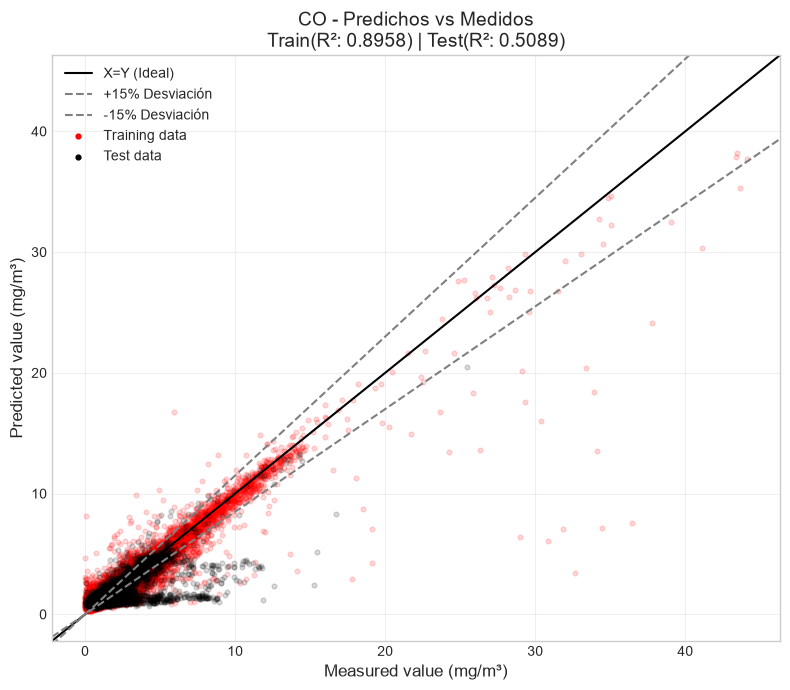


Generando gráfico: muestra del Train Set...


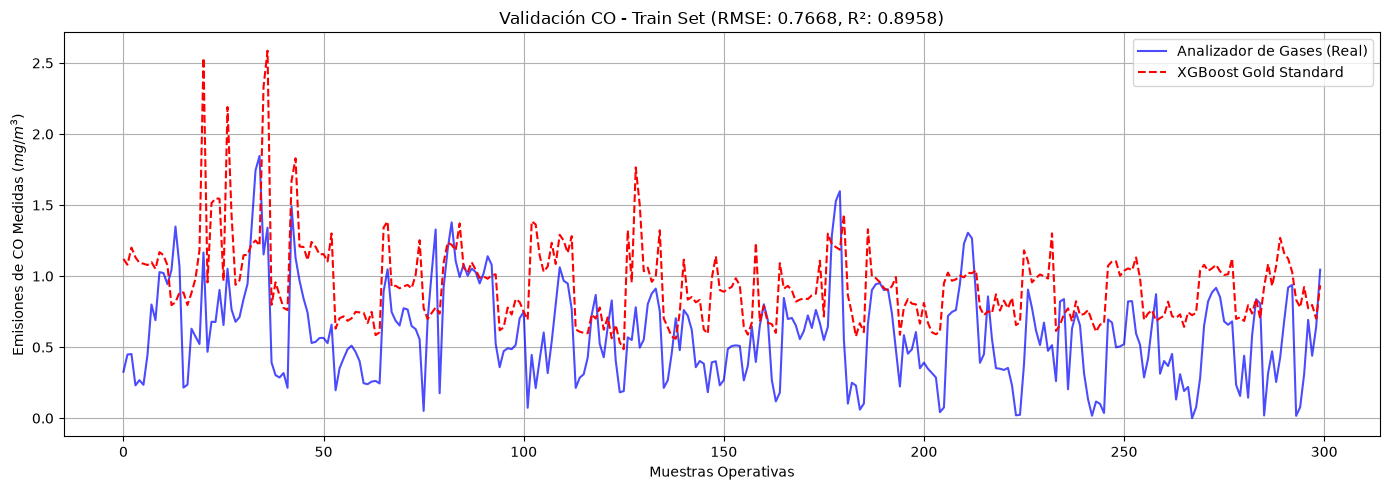


Generando gráfico: muestra del Test Set (Interpolación)...


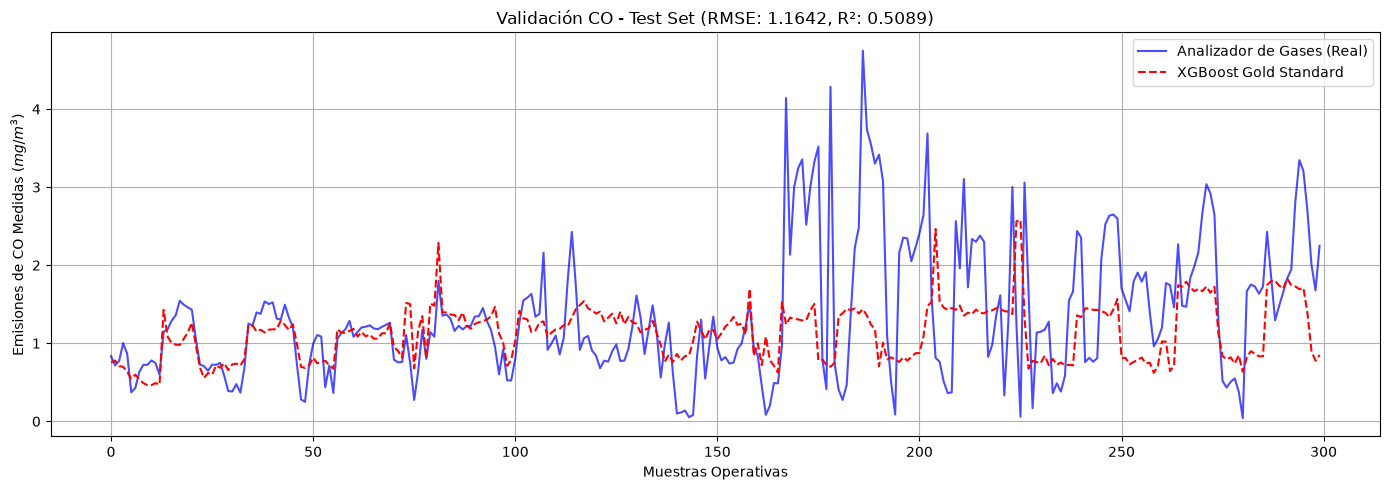

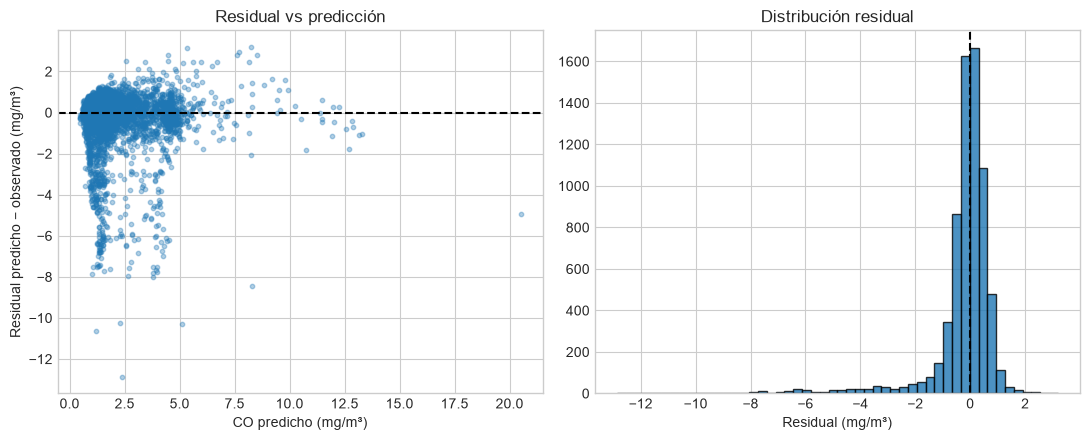

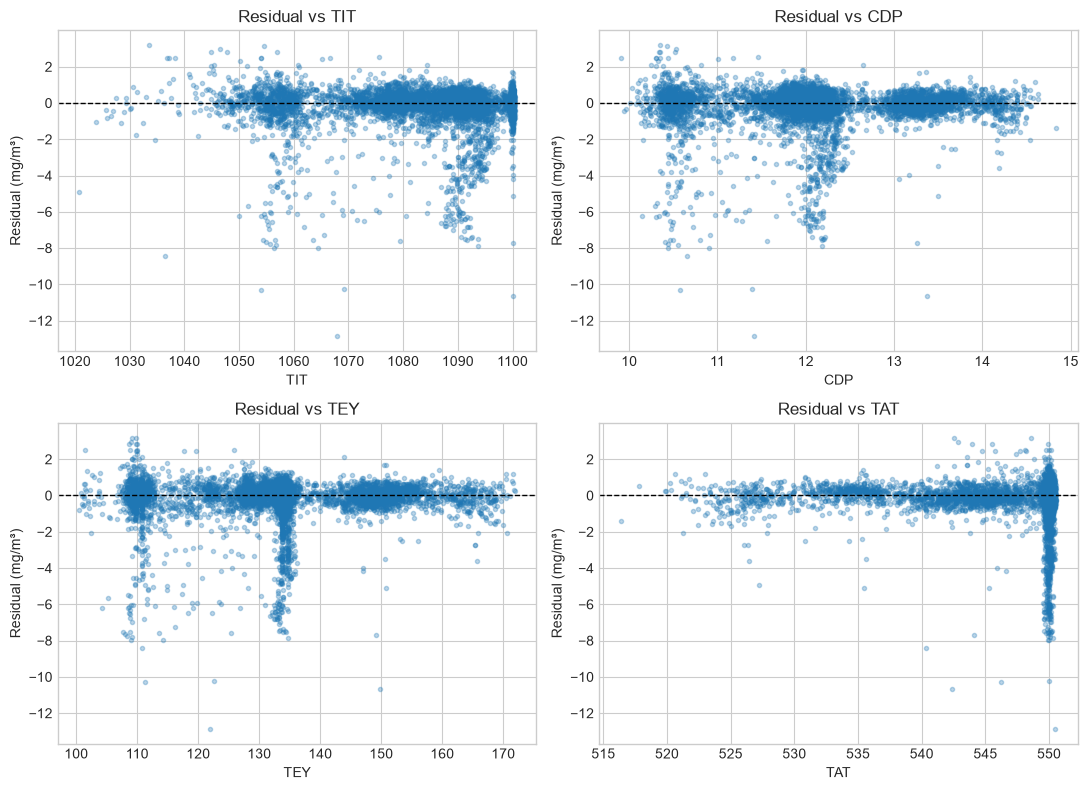

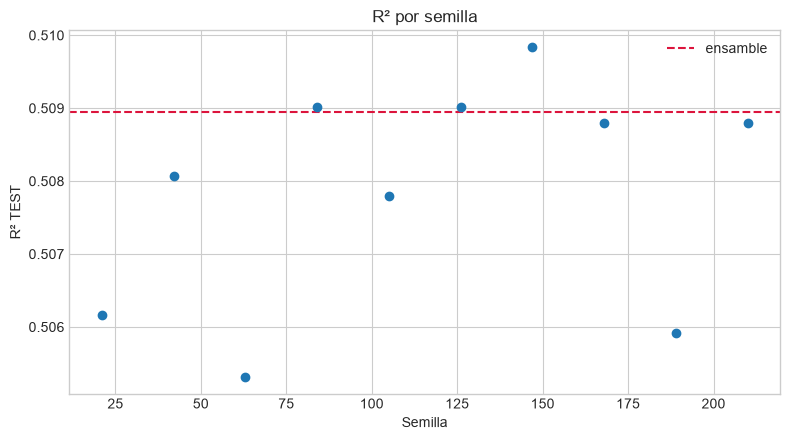

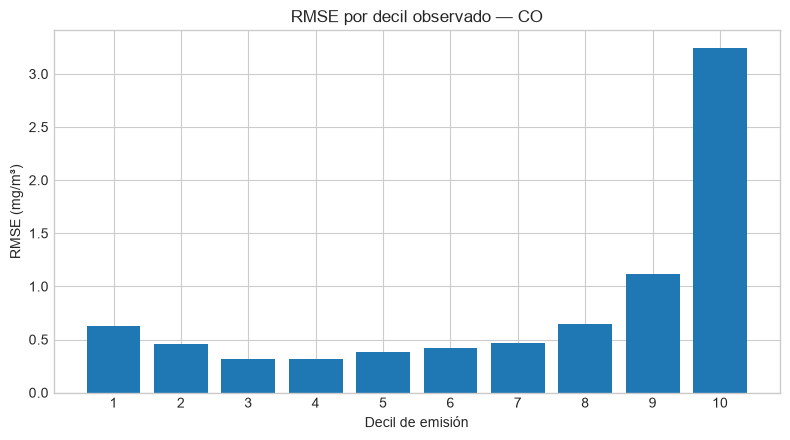

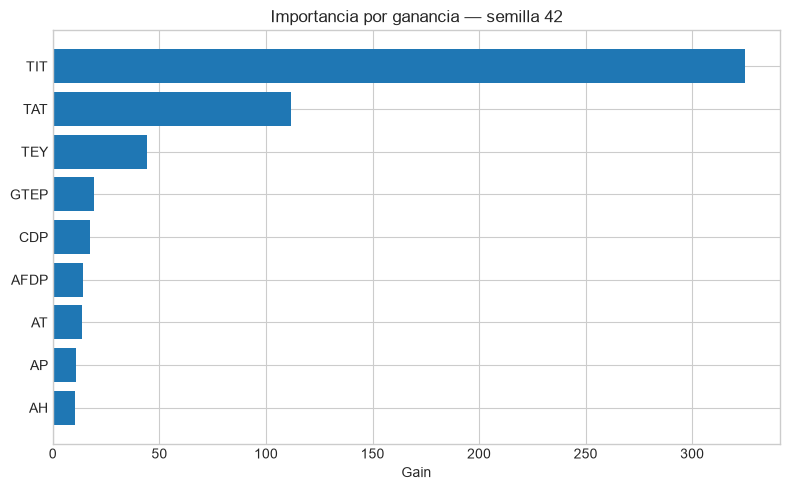

In [11]:
# [C-07.01] Figuras predictivas y de importancia
plt.style.use("seaborn-v0_8-whitegrid")


def save_figure(figure, path: Path) -> None:
    figure.tight_layout()
    figure.savefig(path, dpi=170, bbox_inches="tight")
    plt.show()


print(f"\nGenerando gráfico combinado de predichos vs. medidos para {TARGET}...")

# DEV se incorpora únicamente para reproducir la figura histórica. No interviene
# en la evaluación TEST ni modifica modelos, árboles, semillas o configuración.
y_dev = DEV_DATA[TARGET].to_numpy(float)
dev_prediction_matrix = []
for seed in FINAL_SEEDS:
    predicted_dev_model = FINAL_MODELS[seed].predict(x_dev)
    dev_prediction_matrix.append(
        target_inverse(predicted_dev_model, target_transform)
    )
dev_ensemble = np.mean(np.vstack(dev_prediction_matrix), axis=0)
dev_ensemble_metrics = predictive_metrics(y_dev, dev_ensemble)
observed = y_test
ensemble = ENSEMBLE_PREDICTION

minimum_value = min(
    float(y_dev.min()),
    float(observed.min()),
    float(dev_ensemble.min()),
    float(ensemble.min()),
)
maximum_value = max(
    float(y_dev.max()),
    float(observed.max()),
    float(dev_ensemble.max()),
    float(ensemble.max()),
)
margin = (maximum_value - minimum_value) * 0.05
limits = [minimum_value - margin, maximum_value + margin]
limits_array = np.asarray(limits)
target_label = "NOx" if TARGET == "NOX" else TARGET

figure, axis = plt.subplots(figsize=(8, 7))
axis.plot(
    limits,
    limits,
    color="black",
    label="X=Y (Ideal)",
    linestyle="-",
    linewidth=1.5,
)
axis.plot(
    limits_array,
    limits_array * 1.15,
    color="gray",
    label="+15% Desviación",
    linestyle="--",
)
axis.plot(
    limits_array,
    limits_array * 0.85,
    color="gray",
    label="-15% Desviación",
    linestyle="--",
)
axis.scatter(
    y_dev,
    dev_ensemble,
    color="red",
    label="Training data",
    s=12,
    alpha=0.15,
)
axis.scatter(
    observed,
    ensemble,
    color="black",
    label="Test data",
    s=12,
    alpha=0.15,
)
axis.set_ylabel("Predicted value (mg/m³)", fontsize=12)
axis.set_xlabel("Measured value (mg/m³)", fontsize=12)
axis.set_xlim(limits)
axis.set_ylim(limits)
axis.set_title(
    f"{target_label} - Predichos vs Medidos\n"
    f"Train(R²: {dev_ensemble_metrics['R2']:.4f}) | "
    f"Test(R²: {ENSEMBLE_METRICS['R2']:.4f})",
    fontsize=14,
)
legend = axis.legend(loc="upper left", fontsize=10)
for legend_handle in legend.legend_handles:
    legend_handle.set_alpha(1.0)
axis.grid(True, alpha=0.3)
save_figure(figure, PATHS.figures_test / "01_paridad_ensamble_test.png")

OPERATIONAL_SAMPLE_ROWS = 300


def plot_co_operational_sample(
    y_true: np.ndarray,
    predicted: np.ndarray,
    split_type: str,
    metrics: dict,
    output_path: Path,
) -> None:
    """Reproduce para CO los paneles operativos DEV y TEST del referente PINN."""
    sample_rows = min(OPERATIONAL_SAMPLE_ROWS, len(y_true), len(predicted))
    with plt.style.context("default"):
        figure, axis = plt.subplots(figsize=(14, 5))
        axis.plot(
            y_true[:sample_rows],
            label="Analizador de Gases (Real)",
            color="blue",
            alpha=0.7,
        )
        axis.plot(
            predicted[:sample_rows],
            label="XGBoost Gold Standard",
            color="red",
            linestyle="dashed",
        )
        axis.set_title(
            f"Validación CO - {split_type} "
            f"(RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f})"
        )
        axis.set_ylabel(r"Emisiones de CO Medidas ($mg/m^3$)")
        axis.set_xlabel("Muestras Operativas")
        axis.legend()
        axis.grid(True)
        save_figure(figure, output_path)


print("\nGenerando gráfico: muestra del Train Set...")
plot_co_operational_sample(
    y_dev,
    dev_ensemble,
    "Train Set",
    dev_ensemble_metrics,
    PATHS.figures_test / "02_serie_ensamble_DEV.png",
)

print("\nGenerando gráfico: muestra del Test Set (Interpolación)...")
plot_co_operational_sample(
    observed,
    ensemble,
    "Test Set",
    ENSEMBLE_METRICS,
    PATHS.figures_test / "02_serie_ensamble_test.png",
)

residual = ENSEMBLE_PREDICTION - y_test
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(ENSEMBLE_PREDICTION, residual, s=10, alpha=0.35)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set(
    title="Residual vs predicción",
    xlabel=f"{TARGET} predicho (mg/m³)",
    ylabel="Residual predicho − observado (mg/m³)",
)
axes[1].hist(residual, bins=50, edgecolor="black", alpha=0.8)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(title="Distribución residual", xlabel="Residual (mg/m³)")
save_figure(figure, PATHS.figures_test / "03_diagnostico_residuales_test.png")

key_features = ["AT", "TIT", "TEY", "CDP"] if TARGET == "NOX" else [
    "TIT", "CDP", "TEY", "TAT"
]
figure, axes = plt.subplots(2, 2, figsize=(11, 8))
for axis, feature in zip(axes.ravel(), key_features):
    axis.scatter(TEST_DATA[feature], residual, s=9, alpha=0.30)
    axis.axhline(0, color="black", linestyle="--", linewidth=1)
    axis.set(xlabel=feature, ylabel="Residual (mg/m³)", title=f"Residual vs {feature}")
save_figure(figure, PATHS.figures_test / "04_residuales_variables_operativas.png")

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.errorbar(
    TEST_METRICS_BY_SEED.seed,
    TEST_METRICS_BY_SEED.R2,
    fmt="o",
)
axis.axhline(ENSEMBLE_METRICS["R2"], color="crimson", linestyle="--", label="ensamble")
axis.set(title="R² por semilla", xlabel="Semilla", ylabel="R² TEST")
axis.legend()
save_figure(figure, PATHS.figures_summary / "05_r2_por_semilla.png")

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.bar(DECILE_METRICS.decile.astype(str), DECILE_METRICS.RMSE)
axis.set(
    title=f"RMSE por decil observado — {TARGET}",
    xlabel="Decil de emisión",
    ylabel="RMSE (mg/m³)",
)
save_figure(figure, PATHS.figures_summary / "06_rmse_por_decil.png")

representative_booster = FINAL_MODELS[REPRESENTATIVE_SEED].get_booster()
gain = representative_booster.get_score(importance_type="gain")
IMPORTANCE = pd.DataFrame(
    {
        "feature": FEATURES,
        "gain": [float(gain.get(feature, 0.0)) for feature in FEATURES],
    }
).sort_values("gain", ascending=True)
atomic_csv(PATHS.tables / "feature_importance_gain_seed42.csv", IMPORTANCE)
figure, axis = plt.subplots(figsize=(8, 5))
axis.barh(IMPORTANCE.feature, IMPORTANCE.gain)
axis.set(title="Importancia por ganancia — semilla 42", xlabel="Gain")
save_figure(figure, PATHS.figures_summary / "07_importancia_gain_seed42.png")


## SEC-08 — Complejidad, almacenamiento y latencia CPU

### C-08.01 / TAB-02 / CHK-08 — Huella normalizada

Se separan árboles/nodos/hojas, UBJ desplegable, JSON diagnóstico, tamaño
total del ensamble y latencia. Un nodo no se denomina “parámetro”.


In [12]:
# [C-08.01] Complejidad estructural y benchmark CPU
def tree_depth(node: dict) -> int:
    children = node.get("children", [])
    if not children:
        return 0
    return 1 + max(tree_depth(child) for child in children)


def latency_distribution(operation, warmup: int, repetitions: int) -> dict:
    for _ in range(warmup):
        operation()
    timings = []
    for _ in range(repetitions):
        started = time.perf_counter()
        operation()
        timings.append((time.perf_counter() - started) * 1000)
    return {
        "median_ms": float(np.median(timings)),
        "p95_ms": float(np.quantile(timings, 0.95)),
        "p99_ms": float(np.quantile(timings, 0.99)),
    }


representative_path = (
    PATHS.models / f"XGBOOST_{TARGET}_INTERP_seed{REPRESENTATIVE_SEED}.ubj"
)
cpu_booster = xgb.Booster()
cpu_booster.load_model(representative_path)
cpu_booster.set_param({"device": "cpu", "nthread": 1})
tree_frame = cpu_booster.trees_to_dataframe()
dumps = [json.loads(item) for item in cpu_booster.get_dump(dump_format="json")]
effective_depths = [tree_depth(tree) for tree in dumps]

with tempfile.NamedTemporaryFile(suffix=".json", delete=False) as handle:
    json_path = Path(handle.name)
try:
    cpu_booster.save_model(json_path)
    json_bytes = json_path.stat().st_size
finally:
    json_path.unlink(missing_ok=True)

x_one = TEST_DATA[FEATURES].iloc[:1].to_numpy(np.float32)
x_batch = TEST_DATA[FEATURES].to_numpy(np.float32)

def engine_operation() -> None:
    cpu_booster.inplace_predict(x_one, validate_features=False)


def end_to_end_operation() -> None:
    if not np.isfinite(x_one).all():
        raise ValueError("Entrada no finita")
    predicted_model = cpu_booster.inplace_predict(
        x_one,
        validate_features=False,
    )
    target_inverse(predicted_model, target_transform)


engine_latency = latency_distribution(
    engine_operation,
    LATENCY_WARMUP,
    LATENCY_REPETITIONS,
)
end_to_end_latency = latency_distribution(
    end_to_end_operation,
    LATENCY_WARMUP,
    LATENCY_REPETITIONS,
)

def batch_operation() -> None:
    cpu_booster.inplace_predict(x_batch, validate_features=False)


batch_latency = latency_distribution(
    batch_operation,
    THROUGHPUT_WARMUP,
    THROUGHPUT_REPETITIONS,
)
throughput = float(
    len(x_batch) / (batch_latency["median_ms"] / 1000)
)
ensemble_bytes = int(sum(path.stat().st_size for path in model_files))
FOOTPRINT = {
    "measurement_scope": "representative_seed_model_and_full_ensemble_storage",
    "representative_seed": REPRESENTATIVE_SEED,
    "tree_count": int(tree_frame.Tree.nunique()),
    "node_count": int(len(tree_frame)),
    "leaf_count": int(tree_frame.Feature.eq("Leaf").sum()),
    "effective_depth_max": int(max(effective_depths)),
    "effective_depth_median": float(np.median(effective_depths)),
    "configured_max_depth": int(BEST_CONFIG["xgb_parameters"]["max_depth"]),
    "serialized_ubj_mib": float(representative_path.stat().st_size / 2**20),
    "serialized_json_mib": float(json_bytes / 2**20),
    "ensemble_ubj_mib": float(ensemble_bytes / 2**20),
    "ensemble_model_count": len(FINAL_SEEDS),
    "model_storage_format": "UBJ",
    "cpu_model": platform.processor() or platform.machine(),
    "cpu_platform": platform.platform(),
    "cpu_physical_cores": psutil.cpu_count(logical=False),
    "cpu_logical_threads": psutil.cpu_count(logical=True),
    "benchmark_device": "cpu",
    "benchmark_threads": 1,
    "latency_batch_size": 1,
    "latency_warmup": LATENCY_WARMUP,
    "latency_repetitions": LATENCY_REPETITIONS,
    "throughput_warmup": THROUGHPUT_WARMUP,
    "throughput_repetitions": THROUGHPUT_REPETITIONS,
    "engine_latency_definition": "preprocessed_X_to_model_output",
    "end_to_end_latency_definition": "finite_check_model_inverse_target",
    "engine_latency_cpu_median_ms": engine_latency["median_ms"],
    "engine_latency_cpu_p95_ms": engine_latency["p95_ms"],
    "engine_latency_cpu_p99_ms": engine_latency["p99_ms"],
    "end_to_end_latency_cpu_median_ms": end_to_end_latency["median_ms"],
    "end_to_end_latency_cpu_p95_ms": end_to_end_latency["p95_ms"],
    "end_to_end_latency_cpu_p99_ms": end_to_end_latency["p99_ms"],
    "throughput_batch_rows": len(x_batch),
    "throughput_cpu_samples_per_s": throughput,
    "throughput_batch_median_ms": batch_latency["median_ms"],
    "storage_note": "UBJ and JSON are serialization sizes, not RAM",
}
FOOTPRINT_TABLE = pd.DataFrame([FOOTPRINT])
atomic_csv(PATHS.tables / "model_complexity.csv", FOOTPRINT_TABLE)
atomic_csv(PATHS.tables / "computational_footprint.csv", FOOTPRINT_TABLE)
atomic_json(PATHS.tables / "computational_footprint.json", FOOTPRINT)

separator = "=" * 68
target_label = "NOx" if TARGET == "NOX" else TARGET
print(separator)
print(f"HUELLA COMPUTACIONAL - XGBOOST {target_label} INTERPOLATIVO")
print(separator)
print("Complejidad estructural")
print(f"Árboles                      : {FOOTPRINT['tree_count']:,}")
print(f"Nodos totales                : {FOOTPRINT['node_count']:,}")
print(f"Hojas totales                : {FOOTPRINT['leaf_count']:,}")
print(
    "Profundidad máxima efectiva: "
    f"{FOOTPRINT['effective_depth_max']}"
)
print(
    "Profundidad mediana efectiva: "
    f"{FOOTPRINT['effective_depth_median']:.1f}"
)
print(
    "Profundidad máxima configurada: "
    f"{FOOTPRINT['configured_max_depth']}"
)
print("Almacenamiento serializado (no equivale a RAM)")
print(
    "Modelo UBJ representativo  : "
    f"{FOOTPRINT['serialized_ubj_mib']:.6f} MiB"
)
print(
    "Modelo JSON diagnóstico    : "
    f"{FOOTPRINT['serialized_json_mib']:.6f} MiB"
)
print(
    "Ensamble UBJ (10 modelos)  : "
    f"{FOOTPRINT['ensemble_ubj_mib']:.6f} MiB"
)
print("Inferencia CPU - batch = 1")
print(f"Hilos del benchmark          : {FOOTPRINT['benchmark_threads']}")
print(f"Warm-up                      : {FOOTPRINT['latency_warmup']}")
print(f"Repeticiones                 : {FOOTPRINT['latency_repetitions']}")
print(
    "Latencia motor mediana     : "
    f"{FOOTPRINT['engine_latency_cpu_median_ms']:.6f} ms"
)
print(
    "Latencia motor p95         : "
    f"{FOOTPRINT['engine_latency_cpu_p95_ms']:.6f} ms"
)
print(
    "Latencia motor p99         : "
    f"{FOOTPRINT['engine_latency_cpu_p99_ms']:.6f} ms"
)
print(
    "Latencia end-to-end mediana: "
    f"{FOOTPRINT['end_to_end_latency_cpu_median_ms']:.6f} ms"
)
print(
    "Latencia end-to-end p95    : "
    f"{FOOTPRINT['end_to_end_latency_cpu_p95_ms']:.6f} ms"
)
print(
    "Latencia end-to-end p99    : "
    f"{FOOTPRINT['end_to_end_latency_cpu_p99_ms']:.6f} ms"
)
print("Procesamiento por lotes")
print(f"Filas por lote               : {FOOTPRINT['throughput_batch_rows']:,}")
print(f"Warm-up de lotes             : {FOOTPRINT['throughput_warmup']}")
print(f"Repeticiones de lotes        : {FOOTPRINT['throughput_repetitions']}")
print(
    "Latencia mediana del lote  : "
    f"{FOOTPRINT['throughput_batch_median_ms']:.6f} ms"
)
print(
    "Throughput CPU             : "
    f"{FOOTPRINT['throughput_cpu_samples_per_s']:.3f} muestras/s"
)
print(separator)
display(FOOTPRINT_TABLE.T.rename(columns={0: "valor"}))


HUELLA COMPUTACIONAL - XGBOOST CO INTERPOLATIVO
Complejidad estructural
Árboles                      : 320
Nodos totales                : 54,838
Hojas totales                : 27,579
Profundidad máxima efectiva: 8
Profundidad mediana efectiva: 8.0
Profundidad máxima configurada: 8
Almacenamiento serializado (no equivale a RAM)
Modelo UBJ representativo  : 1.980263 MiB
Modelo JSON diagnóstico    : 2.917743 MiB
Ensamble UBJ (10 modelos)  : 19.762773 MiB
Inferencia CPU - batch = 1
Hilos del benchmark          : 1
Warm-up                      : 50
Repeticiones                 : 200
Latencia motor mediana     : 0.082400 ms
Latencia motor p95         : 0.160095 ms
Latencia motor p99         : 0.215013 ms
Latencia end-to-end mediana: 0.085800 ms
Latencia end-to-end p95    : 0.155885 ms
Latencia end-to-end p99    : 0.199138 ms
Procesamiento por lotes
Filas por lote               : 6,888
Warm-up de lotes             : 10
Repeticiones de lotes        : 30
Latencia mediana del lote  : 29.806300 m

,valor
measurement_scope,representative_seed_model_and_full_ensemble_st...
representative_seed,42
tree_count,320
node_count,54838
leaf_count,27579
effective_depth_max,8
effective_depth_median,8.0
configured_max_depth,8
serialized_ubj_mib,1.980263
serialized_json_mib,2.917743


## SEC-09 — Persistencia, manifiesto y cierre

### C-09.01 / ART-04 — Copia trazable e informe técnico

Se preservan hashes de las entradas OPT y se documentan alcance y
limitaciones antes de cerrar la evaluación.


In [13]:
# [C-09.01] Copia FROZEN e informe
source_config = FROZEN["paths"]["best_config"]
source_policy = FROZEN["paths"]["policy"]
copied_config = PATHS.configs / source_config.name
copied_policy = PATHS.configs / source_policy.name
shutil.copy2(source_config, copied_config)
shutil.copy2(source_policy, copied_policy)
if sha256_file(source_config) != sha256_file(copied_config):
    raise RuntimeError("La copia de BEST_CONFIG alteró el hash")
if sha256_file(source_policy) != sha256_file(copied_policy):
    raise RuntimeError("La copia de la política alteró el hash")

input_snapshot = {
    "status": "VERIFIED",
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "protocol_version": PROTOCOL_VERSION,
    "opt_version": OPT_VERSION,
    "protocol_notebook": PROTOCOL_NOTEBOOK_NAME,
    "opt_notebook": OPT_NOTEBOOK_NAME,
    "config_hash": BEST_CONFIG["config_hash"],
    "row_assignment_sha256": FROZEN["assignment_hash"],
    "fold_assignment_sha256": FROZEN["fold_hash"],
    "best_config_file_sha256": sha256_file(source_config),
    "training_policy_file_sha256": sha256_file(source_policy),
    "pre_test_gate_sha256": PRE_TEST_GATE["gate_sha256"],
}
atomic_json(PATHS.configs / "FROZEN_INPUT_SNAPSHOT_R1F_STD.json", input_snapshot)

report = f'''# Informe técnico — XGBoost {TARGET} interpolativo FINAL R1F_STD

## Diseño

Se consumió sin cambios la configuración {BEST_CONFIG['config_hash']} y la
política de {FINAL_N_ESTIMATORS} árboles. Se entrenaron diez modelos con DEV
completo antes de abrir TEST. El ensamble es la media aritmética de las diez
semillas predeclaradas. No se aplicaron restricciones monotónicas, pérdida
física, sintéticos, selección de variables, escalamiento de X ni clipping.

## Resultado TEST

- R² del ensamble: {ENSEMBLE_METRICS['R2']:.6f}.
- RMSE: {ENSEMBLE_METRICS['RMSE']:.6f} mg/m³.
- MAE: {ENSEMBLE_METRICS['MAE']:.6f} mg/m³.
- Sesgo: {ENSEMBLE_METRICS['bias']:.6f} mg/m³.
- RMSE del decil superior: {ENSEMBLE_METRICS['tail_RMSE']:.6f} mg/m³.
- Predicciones negativas: {ENSEMBLE_METRICS['negative_prediction_pct']:.6f} %.

## Complejidad

- Árboles: {FOOTPRINT['tree_count']}.
- Nodos: {FOOTPRINT['node_count']}.
- Hojas: {FOOTPRINT['leaf_count']}.
- UBJ representativo: {FOOTPRINT['serialized_ubj_mib']:.6f} MiB.
- UBJ de diez modelos: {FOOTPRINT['ensemble_ubj_mib']:.6f} MiB.
- Latencia CPU motor, batch=1: mediana=
  {FOOTPRINT['engine_latency_cpu_median_ms']:.6f} ms,
  p95={FOOTPRINT['engine_latency_cpu_p95_ms']:.6f} ms y
  p99={FOOTPRINT['engine_latency_cpu_p99_ms']:.6f} ms.
- Latencia CPU end-to-end, batch=1: mediana=
  {FOOTPRINT['end_to_end_latency_cpu_median_ms']:.6f} ms,
  p95={FOOTPRINT['end_to_end_latency_cpu_p95_ms']:.6f} ms y
  p99={FOOTPRINT['end_to_end_latency_cpu_p99_ms']:.6f} ms.
- Throughput CPU sobre {FOOTPRINT['throughput_batch_rows']} filas:
  {FOOTPRINT['throughput_cpu_samples_per_s']:.3f} muestras/s.

## Alcance

Los resultados describen interpolación dentro del soporte operativo del
protocolo R1. No demuestran transferencia temporal, extrapolación, relación
causal ni conformidad regulatoria PEMS/CEMS/RATA.
'''
atomic_text(
    PATHS.reports / "INFORME_TECNICO_XGBOOST_CO_INTERP_FINAL_R1F_STD.md",
    report,
)


### C-09.02 / ART-05 / CHK-09 — Manifiesto final y hashes

El cierre exige diez modelos, apertura única de TEST, tablas, figuras y
huella computacional. Los artefactos quedan inventariados con SHA-256.


In [14]:
# [C-09.02] Manifiesto final e inventario
required_files = [
    PATHS.audit / "ENVIRONMENT_XGBOOST_CO_FINAL_R1F_STD.json",
    PATHS.audit / "TARGET_ACCESS_AUDIT_PRE_TEST_R1F_STD.json",
    PATHS.audit / "PRE_TEST_GATE_R1F_STD.json",
    PATHS.audit / "TEST_ACCESS_AUDIT_R1F_STD.json",
    copied_config,
    copied_policy,
    PATHS.configs / "FROZEN_INPUT_SNAPSHOT_R1F_STD.json",
    PATHS.tables / "training_summary_by_seed.csv",
    PATHS.tables / "test_predictions.csv",
    PATHS.tables / "test_metrics_by_seed.csv",
    PATHS.tables / "test_metrics_ensemble.json",
    PATHS.tables / "test_summary_multiseed.csv",
    PATHS.tables / "test_metrics_by_decile.csv",
    PATHS.tables / "feature_importance_gain_seed42.csv",
    PATHS.tables / "model_complexity.csv",
    PATHS.tables / "computational_footprint.csv",
    PATHS.tables / "computational_footprint.json",
    PATHS.reports / "INFORME_TECNICO_XGBOOST_CO_INTERP_FINAL_R1F_STD.md",
]
required_files.extend(model_files)
required_files.extend(metadata_files)
required_files.extend(sorted(PATHS.figures_test.glob("*.png")))
required_files.extend(sorted(PATHS.figures_summary.glob("*.png")))
missing = [str(path) for path in required_files if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Artefactos finales ausentes: {missing}")
if TEST_ACCESS_COUNT != 1 or not TEST_ACCESS_AUDIT["opened_once"]:
    raise RuntimeError("Contrato de apertura única de TEST violado")
if model_hashes_before_test != {
    path.name: sha256_file(path) for path in model_files
}:
    raise RuntimeError("Un modelo cambió después de abrir TEST")
if metadata_hashes_before_test != {
    path.name: sha256_file(path) for path in metadata_files
}:
    raise RuntimeError("Un sidecar cambió después de abrir TEST")

ARTIFACT_HASHES = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(PATHS.work)).replace("\\", "/"),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for path in sorted(set(required_files))
    ]
)
atomic_csv(
    PATHS.audit / "HASHES_XGBOOST_CO_INTERP_FINAL_R1F_STD.csv",
    ARTIFACT_HASHES,
)
FINAL_MANIFEST = {
    "status": "COMPLETE",
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "scope": "holdout interpolativo intradominio",
    "producer_notebook": CURRENT_NOTEBOOK_NAME,
    "upstream_notebooks": [PROTOCOL_NOTEBOOK_NAME, OPT_NOTEBOOK_NAME],
    "protocol_version": PROTOCOL_VERSION,
    "opt_version": OPT_VERSION,
    "config_hash": BEST_CONFIG["config_hash"],
    "target": TARGET,
    "features": FEATURES,
    "target_transform": target_transform,
    "pure_data_driven_contract": BEST_CONFIG[
        "pure_data_driven_contract"
    ],
    "final_n_estimators": FINAL_N_ESTIMATORS,
    "final_seeds": FINAL_SEEDS,
    "ensemble_rule": ENSEMBLE_RULE,
    "models_frozen_before_test": True,
    "test_opened_once": True,
    "test_access_count": TEST_ACCESS_COUNT,
    "dev_rows": len(DEV_DATA),
    "test_rows": len(TEST_DATA),
    "training_elapsed_seconds": FINAL_TRAINING_SECONDS,
    "ensemble_metrics": ENSEMBLE_METRICS,
    "computational_footprint": FOOTPRINT,
    "artifact_count": len(ARTIFACT_HASHES),
    "artifacts": ARTIFACT_HASHES.to_dict(orient="records"),
    "limitations": [
        "No valida transferencia temporal.",
        "No demuestra extrapolación fuera del dominio.",
        "No equivale a certificación PEMS, RATA ni homologación regulatoria.",
    ],
}
atomic_json(
    PATHS.work / "MANIFEST_XGBOOST_CO_INTERP_FINAL_R1F_STD.json",
    FINAL_MANIFEST,
)
print(
    {
        "estado": FINAL_MANIFEST["status"],
        "CHK-09": "PASS",
        "modelos": len(FINAL_SEEDS),
        "artefactos": len(ARTIFACT_HASHES),
        "TEST_abierto_una_vez": True,
        "salida": str(PATHS.work),
    }
)


{'estado': 'COMPLETE', 'CHK-09': 'PASS', 'modelos': 10, 'artefactos': 46, 'TEST_abierto_una_vez': True, 'salida': 'C:\\ChatGPT-Work\\Walk_Forward R8\\models\\interp\\work_xgboost_co_interp_final_r1f_std'}


## OUT-01 — Resumen ejecutivo

El notebook entrena diez modelos XGBoost con configuración DEV-only
congelada, abre TEST una sola vez y conserva todas las semillas en el
ensamble. Las métricas y la complejidad deben interpretarse dentro del
escenario interpolativo; el escenario walk-forward responde la pregunta de
transferencia temporal.

## Registro de versión

**R1F_STD:** primera evaluación final XGBoost interpolativa para CO,
estandarizada según Manual R4 y compatible con la estructura Colab del
proyecto.
